# Данные: оптические стёкла
Источники: **SciGlass** (glasspy) + **SCHOTT** каталог (PDF)

In [1]:
import sys
sys.path.insert(0, 'C:/Users/user/AppData/Roaming/Python/Python314/site-packages')
import numpy as np
import pandas as pd
print('OK')

OK


## 1. SciGlass — свойства (~422k стёкол)

In [2]:
import glasspy

In [19]:
glasspy.data.translators.prop_units.values

<function dict.values()>

In [3]:
import zipfile, io
from pathlib import Path

DATA_DIR = Path('C:/Users/user/AppData/Local/GlassPy/GlassPy/data')

# Свойства: n, v, Tg, плотность, КТР и др.
with zipfile.ZipFile(DATA_DIR / 'select_SciGK.csv.zip') as z:
    with z.open(z.namelist()[0]) as f:
        df_props = pd.read_csv(f, sep='\t', low_memory=False)

df_props['ID'] = df_props['KOD'] * 100_000_000 + df_props['GLASNO']
df_props = df_props.drop_duplicates('ID').set_index('ID')

print(f'Свойства: {df_props.shape[0]:,} записей, {df_props.shape[1]} колонок')
print('Колонки:', df_props.columns.tolist())

C:\Temp\ipykernel_3068\2750312754.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_props['ID'] = df_props['KOD'] * 100_000_000 + df_props['GLASNO']


Свойства: 422,898 записей, 186 колонок
Колонки: ['KOD', 'GLASNO', 'A_WT', 'M_WT', 'SIO2', 'AL2O3', 'B2O3', 'CAO', 'K2O', 'NA2O', 'PBO', 'Li2O', 'MgO', 'SRO', 'BAO', 'ZNO', 'P2O5', 'GEO2', 'ZRO2', 'TIO2', 'TEO2', 'RO', 'FemOn', 'WSIO2', 'WAL2O3', 'WB2O3', 'WCAO', 'WK2O', 'WNA2O', 'WPBO', 'WLi2O', 'WMgO', 'WSRO', 'WBAO', 'WZNO', 'WGEO2', 'WZRO2', 'WTIO2', 'WTEO2', 'WRO', 'WFemOn', 'WP2O5', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'V500', 'V600', 'V700', 'V800', 'V900', 'V1000', 'V1100', 'V1200', 'V1300', 'V1400', 'V1500', 'V1600', 'V1800', 'V2000', 'V2200', 'TG', 'LPT', 'ANPT', 'SPT', 'Tsoft', 'RO150', 'RO300', 'RO20', 'RO100', 'TK100C', 'TEC55', 'TEC100', 'TEC160', 'TEC210', 'TEC350', 'ANY_TEC', 'DENSITY', 'spvm', 'ND300', 'nd300low', 'nd300hi', 'DNFC300', 'NUD300', 'RTSH180', 'MOD_UNG', 'MOD_SDV', 'MIKROTV', 'EPS730', 'TGD730', 'ro800', 'ro1000', 'ro1200', 'ro1400', 'Tm', 'TLiq', 'SUT900', 'SUT1200', 'SUT1300', 'SUT1400', 'any_sut', 'QComp', 'QC

In [4]:
# Переименовываем нужные колонки
# Смотрим translators glasspy для маппинга
import sys; sys.path.insert(0,'C:/Users/user/AppData/Roaming/Python/Python314/site-packages')
from glasspy.data.translators import SciGK_translation

rename = {k: v['rename'] for k, v in SciGK_translation.items() if 'rename' in v}
df_props = df_props.rename(columns=rename)

# Смотрим заполненность ключевых оптических свойств
key_props = ['RefractiveIndex', 'AbbeNumber', 'Density', 'TransitionTemperature', 'CTE']
for p in key_props:
    if p in df_props.columns:
        nn = df_props[p].replace(0, np.nan).dropna()
        print(f'{p:30s}: {len(nn):>8,}')

RefractiveIndex               :   62,921


## 2. SciGlass — элементный состав

In [5]:
with zipfile.ZipFile(DATA_DIR / 'select_AtMol.csv.zip') as z:
    with z.open(z.namelist()[0]) as f:
        df_elem = pd.read_csv(f, sep='\t', low_memory=False)

df_elem['ID'] = df_elem['Kod'] * 100_000_000 + df_elem['GlasNo']
df_elem = df_elem.drop_duplicates('ID').set_index('ID').drop(columns=['Kod','GlasNo'], errors='ignore')

print(f'Элементный состав: {df_elem.shape[0]:,} записей, {df_elem.shape[1]} элементов')
print('Элементы:', df_elem.columns.tolist()[:30], '...')

Элементный состав: 420,838 записей, 80 элементов
Элементы: ['1', '3', '4', '5', '6', '7', '8', '9', '11', '12', '13', '14', '15', '16', '17', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33'] ...


In [10]:
pd.set_option('display.max_columns',None)
df_props.describe()



,KOD,GLASNO,A_WT,M_WT,SIO2,AL2O3,B2O3,CAO,K2O,NA2O,PBO,Li2O,MgO,SRO,BAO,ZNO,P2O5,GEO2,ZRO2,TIO2,TEO2,RO,FemOn,WSIO2,WAL2O3,WB2O3,WCAO,WK2O,WNA2O,WPBO,WLi2O,WMgO,WSRO,WBAO,WZNO,WGEO2,WZRO2,WTIO2,WTEO2,WRO,WFemOn,WP2O5,T0,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,Viscosity773K,Viscosity873K,Viscosity973K,Viscosity1073K,Viscosity1173K,Viscosity1273K,Viscosity1373K,Viscosity1473K,Viscosity1573K,Viscosity1673K,Viscosity1773K,Viscosity1873K,Viscosity2073K,Viscosity2273K,Viscosity2473K,Tg,TLittletons,TAnnealing,Tstrain,Tsoft,Resistivity423K,Resistivity573K,Resistivity293K,Resistivity373K,TresistivityIs1MOhm.m,CTE328K,CTE373K,CTE433K,CTE483K,CTE623K,CTEbelowTg,Density293K,spvm,RefractiveIndex,RefractiveIndexLow,RefractiveIndexHigh,MeanDispersion,AbbeNum,ThermalShockRes,YoungModulus,ShearModulus,Microhardness,Permittivity,TangentOfLossAngle,Resistivity1073K,Resistivity1273K,Resistivity1473K,Resistivity1673K,Tmelt,Tliquidus,SurfaceTension1173K,SurfaceTension1473K,SurfaceTension1573K,SurfaceTension1673K,SurfaceTensionAboveTg,QComp,QComp2,ThermalConductivity,PoissonRatio,TdilatometricSoftening,Flag,Cp293K,Cp473K,Cp673K,Cp1073K,Cp1273K,Cp1473K,Cp1673K,Density1073K,Density1273K,Density1473K,Density1673K,AsmOn,Bi2O3,R2O,R2O3,RF,RF2,RF3,RF4,RF5,RHal,RHal2,RHal3,RHal4,RHal5,RHaln,RmOn,RmNn,SbmOn,VmOn,WO3,wBi2O3,wR2O,wR2O3,wRF,wRF2,wRF3,wRF4,wRF5,wRHal,wRHal2,wRHal3,wRHal4,wRHal5,wRHaln,wRmNn,wWO3,wRmOn,Year,RO2,R2O5,RO3,RO4,WRO2,WR2O5,WRO3,WRO4,GForm,any_n,TMaxGrowthVelocity,MaxGrowthVelocity,NucleationTemperature,NucleationRate,CrystallizationPeak,CrystallizationOnset
count,422898.000000,4.228980e+05,422898.000000,422898.000000,421205.000000,421868.000000,422217.000000,421662.000000,422393.000000,421920.000000,422756.000000,422670.000000,421875.000000,422836.000000,422738.000000,422755.000000,422692.000000,422892.000000,422622.000000,422619.000000,422882.000000,421432.000000,422441.000000,422898.000000,422898.000000,422898.00000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,1735.000000,8319.000000,16730.000000,14992.000000,8407.000000,6219.000000,5452.000000,5698.000000,6013.000000,6540.000000,7048.000000,6641.000000,5144.000000,2152.000000,3711.000000,4200.000000,4677.000000,5278.000000,6406.000000,8215.000000,10951.000000,12312.000000,11866.000000,8582.000000,4689.000000,252.000000,97.000000,30.000000,92010.000000,4452.000000,9417.000000,11877.000000,14282.000000,17641.000000,13625.000000,16423.000000,16756.000000,14920.000000,2561.000000,2501.000000,19171.000000,16548.000000,1245.000000,67744.000000,98811.000000,98811.000000,62921.000000,435.000000,559.000000,30068.000000,30300.000000,1101.000000,16935.000000,7913.000000,15911.000000,3284.000000,2473.000000,2189.000000,2729.000000,2286.000000,2288.000000,18081.000000,45549.000000,783.000000,963.000000,1333.000000,835.000000,4109.000000,422898.000000,422898.000000,1440.000000,7575.000000,20026.000000,422898.0,888.000000,759.000000,574.000000,346.000000,208.000000,193.000000,147.000000,975.000000,1171.000000,930.000000,942.000000,422880.000000,422840.000000,421869.000000,421619.000000,422898.000000,422844.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.0,422898.0,422898.0,422898.0,422844.000000,421189.000000,422898.000000,422883.000000,422898.000000,422889.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422898.0,422898.0,422898.0,422898.0,422898.000000,422898.000000,422898.000000,422898.000000,422898.000000,422371.000000,422673.000000,422717.000000,0.0,422898.000000,422898.000000,422898.000000,0.0,422898.0,0.0,847.000000,8.490000e+02,161.000000,1.430000e+02,24190.000000,13724.000000
mean,23075.017049,5.207954e+05,35.724391,111.199889,23.988544,2.703430,10.339683,3.833745,1.585248,4.375862,2.775089,2.105944,1.615163

In [23]:
# Импортируем CSV с нестандартным разделителем (\t) и кавычками (") в заголовках — pandas справится автоматически
mol_data = pd.read_csv(
    r'C:\Users\user\Documents\Great_power_great_responsibility\Ближайшее\Хакатон\AtMol.csv',
    sep='\t'
)
display(mol_data.head())

,Kod,GlasNo,1,3,4,5,6,7,8,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,37,38,39,40,41,42,44,45,46,47,48,49,50,51,52,53,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,90,92
0,204,20000,0.0,0.0,0.0,0.0,0.0,0.0,66.666656,0.0,0.000000,0.0,0.0,33.333328,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
1,205,20001,0.0,0.0,0.0,0.0,0.0,0.0,57.921249,0.0,19.681530,0.0,0.0,13.129700,6.572090,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.695426,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
2,205,20002,0.0,0.0,0.0,0.0,0.0,0.0,58.086941,0.0,19.344940,0.0,0.0,11.580900,6.556427,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.430801,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
3,205,20003,0.0,0.0,0.0,0.0,0.0,0.0,58.198601,0.0,18.716690,0.0,0.0,14.482650,5.341671,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.260384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
4,205,20004,0.0,0.0,0.0,0.0,0.0,0.0,58.367241,0.0,18.308001,0.0,0.0,14.431020,5.127438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.766303,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0


In [30]:
# Переименовываем числовые колонки mol_data по атомным номерам в символы элементов
num2el = {
    '1': 'H', '2': 'He', '3': 'Li', '4': 'Be', '5': 'B', '6': 'C', '7': 'N', '8': 'O', '9': 'F', '10': 'Ne',
    '11': 'Na', '12': 'Mg', '13': 'Al', '14': 'Si', '15': 'P', '16': 'S', '17': 'Cl', '18': 'Ar', '19': 'K', '20': 'Ca',
    '21': 'Sc', '22': 'Ti', '23': 'V', '24': 'Cr', '25': 'Mn', '26': 'Fe', '27': 'Co', '28': 'Ni', '29': 'Cu', '30': 'Zn',
    '31': 'Ga', '32': 'Ge', '33': 'As', '34': 'Se', '35': 'Br', '36': 'Kr', '37': 'Rb', '38': 'Sr', '39': 'Y', '40': 'Zr',
    '41': 'Nb', '42': 'Mo', '43': 'Tc', '44': 'Ru', '45': 'Rh', '46': 'Pd', '47': 'Ag', '48': 'Cd', '49': 'In', '50': 'Sn',
    '51': 'Sb', '52': 'Te', '53': 'I', '54': 'Xe', '55': 'Cs', '56': 'Ba', '57': 'La', '58': 'Ce', '59': 'Pr', '60': 'Nd',
    '61': 'Pm', '62': 'Sm', '63': 'Eu', '64': 'Gd', '65': 'Tb', '66': 'Dy', '67': 'Ho', '68': 'Er', '69': 'Tm', '70': 'Yb',
    '71': 'Lu', '72': 'Hf', '73': 'Ta', '74': 'W', '75': 'Re', '76': 'Os', '77': 'Ir', '78': 'Pt', '79': 'Au', '80': 'Hg',
    '81': 'Tl', '82': 'Pb', '83': 'Bi', '84': 'Po', '85': 'At', '86': 'Rn', '87': 'Fr', '88': 'Ra', '89': 'Ac', '90': 'Th',
    '91': 'Pa', '92': 'U', '93': 'Np', '94': 'Pu'
}
rename_dict = {k: num2el[k] for k in mol_data.columns if k in num2el}
mol_data = mol_data.rename(columns=rename_dict)
mol_data.head()

,Kod,GlasNo,H,Li,Be,B,C,N,O,F,Na,Mg,Al,Si,P,S,Cl,K,Ca,Sc,Ti,V,Cr,Mn,Fe,Co,Ni,Cu,Zn,Ga,Ge,As,Se,Br,Rb,Sr,Y,Zr,Nb,Mo,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,Th,U
0,204,20000,0.0,0.0,0.0,0.0,0.0,0.0,66.666656,0.0,0.000000,0.0,0.0,33.333328,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
1,205,20001,0.0,0.0,0.0,0.0,0.0,0.0,57.921249,0.0,19.681530,0.0,0.0,13.129700,6.572090,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.695426,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
2,205,20002,0.0,0.0,0.0,0.0,0.0,0.0,58.086941,0.0,19.344940,0.0,0.0,11.580900,6.556427,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.430801,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
3,205,20003,0.0,0.0,0.0,0.0,0.0,0.0,58.198601,0.0,18.716690,0.0,0.0,14.482650,5.341671,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.260384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
4,205,20004,0.0,0.0,0.0,0.0,0.0,0.0,58.367241,0.0,18.308001,0.0,0.0,14.431020,5.127438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.766303,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0


In [37]:
mol_data.shape[0]

420838

In [40]:
df_props.shape[0]

422898

In [55]:
from typing import Any

intersect_glass = list(set[Any](mol_data['GlasNo'].values).intersection(set(df_props['GLASNO'])))
len(list(set[Any](mol_data['GlasNo'].values).intersection(set(df_props['GLASNO']))))
mol_data = mol_data[mol_data['GlasNo'].isin(intersect_glass)]
df_props = df_props[df_props['GLASNO'].isin(intersect_glass)]
mol_data.shape[0] - df_props.shape[0]


-11

In [58]:
# Проверяем индексы по GlassNo / GLASNO (без учета обычных индексов DataFrame)

# Получаем уникальные значения индекса GlassNo для mol_data и df_props
mol_idx = set(mol_data['GlasNo'])
props_idx = set(df_props['GLASNO'])

print(f'Уникальных GlasNo в mol_data: {len(mol_idx)}')
print(f'Уникальных GLASNO в df_props: {len(props_idx)}')

# Если не совпадают, удаляем строки, у которых нет соответствия
if mol_idx != props_idx:
    print('Найдены несовпадающие значения GlassNo/GLASNO между mol_data и df_props.')
    intersect = mol_idx & props_idx
    print(f'Совпадающих стекол: {len(intersect)}')
    mol_data = mol_data[mol_data['GlasNo'].isin(intersect)].copy()
    df_props = df_props[df_props['GLASNO'].isin(intersect)].copy()

# Проверяем после фильтрации
print(f'После фильтрации - строк в mol_data: {len(mol_data)}')
print(f'После фильтрации - строк в df_props: {len(df_props)}')

Уникальных GlasNo в mol_data: 418701
Уникальных GLASNO в df_props: 418701
После фильтрации - строк в mol_data: 420838
После фильтрации - строк в df_props: 420849


In [59]:
# Объединяем два датасета по столбцу GlassNo/GLASNO

# Приводим имена столбцов к единому виду для объединения
mol_data_merged = mol_data.copy()
df_props_merged = df_props.copy()

mol_data_merged = mol_data_merged.rename(columns={'GlasNo': 'GLASNO'})
# Если GLASNO вдруг не индекс - оставим типичный вариант
if 'GLASNO' not in df_props_merged.columns and df_props_merged.index.name == 'GLASNO':
    df_props_merged = df_props_merged.reset_index()

merged_data = pd.merge(
    mol_data_merged,
    df_props_merged,
    on='GLASNO',
    suffixes=('_mol', '_props'),
    how='inner'  # только те, кто есть в обоих
)

print(f'Объединённый датасет: {merged_data.shape[0]:,} строк, {merged_data.shape[1]} колонок')

Объединённый датасет: 425,293 строк, 267 колонок


## 3. SciGlass — состав в оксидах
> Осторожно: 726 оксидов x 422k строк ~ 2.3 GB. Загружаем только для стёкол с оптическими свойствами.

In [115]:
merged_data.describe()

,Kod,GLASNO,H,Li,Be,B,C,N,O,F,Na,Mg,Al,Si,P,S,Cl,K,Ca,Sc,Ti,V,Cr,Mn,Fe,Co,Ni,Cu,Zn,Ga,Ge,As,Se,Br,Rb,Sr,Y,Zr,Nb,Mo,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,Th,U,KOD,A_WT,M_WT,SIO2,AL2O3,B2O3,CAO,K2O,NA2O,PBO,Li2O,MgO,SRO,BAO,ZNO,P2O5,GEO2,ZRO2,TIO2,TEO2,RO,FemOn,WSIO2,WAL2O3,WB2O3,WCAO,WK2O,WNA2O,WPBO,WLi2O,WMgO,WSRO,WBAO,WZNO,WGEO2,WZRO2,WTIO2,WTEO2,WRO,WFemOn,WP2O5,T0,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,Viscosity773K,Viscosity873K,Viscosity973K,Viscosity1073K,Viscosity1173K,Viscosity1273K,Viscosity1373K,Viscosity1473K,Viscosity1573K,Viscosity1673K,Viscosity1773K,Viscosity1873K,Viscosity2073K,Viscosity2273K,Viscosity2473K,Tg,TLittletons,TAnnealing,Tstrain,Tsoft,Resistivity423K,Resistivity573K,Resistivity293K,Resistivity373K,TresistivityIs1MOhm.m,CTE328K,CTE373K,CTE433K,CTE483K,CTE623K,CTEbelowTg,Density293K,spvm,RefractiveIndex,RefractiveIndexLow,RefractiveIndexHigh,MeanDispersion,AbbeNum,ThermalShockRes,YoungModulus,ShearModulus,Microhardness,Permittivity,TangentOfLossAngle,Resistivity1073K,Resistivity1273K,Resistivity1473K,Resistivity1673K,Tmelt,Tliquidus,SurfaceTension1173K,SurfaceTension1473K,SurfaceTension1573K,SurfaceTension1673K,SurfaceTensionAboveTg,QComp,QComp2,ThermalConductivity,PoissonRatio,TdilatometricSoftening,Flag,Cp293K,Cp473K,Cp673K,Cp1073K,Cp1273K,Cp1473K,Cp1673K,Density1073K,Density1273K,Density1473K,Density1673K,AsmOn,Bi2O3,R2O,R2O3,RF,RF2,RF3,RF4,RF5,RHal,RHal2,RHal3,RHal4,RHal5,RHaln,RmOn,RmNn,SbmOn,VmOn,WO3,wBi2O3,wR2O,wR2O3,wRF,wRF2,wRF3,wRF4,wRF5,wRHal,wRHal2,wRHal3,wRHal4,wRHal5,wRHaln,wRmNn,wWO3,wRmOn,Year,RO2,R2O5,RO3,RO4,WRO2,WR2O5,WRO3,WRO4,GForm,any_n,TMaxGrowthVelocity,MaxGrowthVelocity,NucleationTemperature,NucleationRate,CrystallizationPeak,CrystallizationOnset
count,425293.000000,4.252930e+05,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.00000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.0,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.0,4.252930e+05,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.0,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425200.000000,425242.000000,425260.000000,425231.000000,425265.000000,425249.000000,425279.000000,425288.000000,425243.000000,425293.000000,425280.000000,425287.000000,425289.000000,425293.000000,425287.000000,425267.000000,425293.000000,425219.000000,425274.000000,425293.000000,425293.000000,425293.000000,425293.00000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,425293.000000,1704.000000,8201.000000,16596.000000,14976.000000,8398.000000,6198.000000,5435.000000,5682.000000,5974.000000,6500.000000,7015.000000,6600.000000,5123.000000,2145.000000,3634.000000,4156.000000,4642.000000,5259.000000,6375.000000,8161.000000,10834.000000,12129.000000,11804.000000,8594.000000,4702.000000,248.000000,96.000000,30.000000,93038.000000,4458.000000,9475.000000,11992.000000,14496.000000,17793.000000,13740.000000,16589.000000,16924.000000,15006.000000,2507.000000,2533.0000

# База для графиков и ML

Графики: `plots.py`. Модели: состав элементов → `RefractiveIndex` (1.35 < n < 4).


In [105]:
import importlib
import sys
from pathlib import Path


def _project_dir() -> Path:
    for directory in [Path.cwd(), *Path.cwd().parents]:
        if (directory / "plots.py").is_file():
            return directory
    return Path.cwd()


PROJECT_DIR = _project_dir()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import plots
importlib.reload(plots)  # подхватить изменения без перезапуска ядра

from plots import plot_boxplot, plot_distribution, plot_parity

In [ ]:
# here — ML: состав элементов → RefractiveIndex
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

TARGET = "RefractiveIndex"

ELEMENT_FEATURES = [
    "H", "Li", "Be", "B", "C", "N", "O", "F", "Na", "Mg", "Al", "Si", "P", "S",
    "Cl", "K", "Ca", "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
    "Ga", "Ge", "As", "Se", "Br", "Rb", "Sr", "Y", "Zr", "Nb", "Mo", "Ru", "Rh",
    "Pd", "Ag", "Cd", "In", "Sn", "Sb", "Te", "I", "Cs", "Ba", "La", "Ce", "Pr",
    "Nd", "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu", "Hf",
    "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg", "Tl", "Pb", "Bi", "Po", "Th", "U",
]

feature_cols = [c for c in ELEMENT_FEATURES if c in merged_data.columns]
missing_elems = [c for c in ELEMENT_FEATURES if c not in merged_data.columns]

n_raw = merged_data[TARGET].replace(0, np.nan)
valid_n = n_raw.notna() & (n_raw > 1.35) & (n_raw < 4)

ml_df = merged_data.loc[valid_n, feature_cols + [TARGET]].copy()
ml_df[TARGET] = n_raw.loc[valid_n]
ml_df[feature_cols] = ml_df[feature_cols].fillna(0)
ml_df = ml_df.dropna(subset=[TARGET])

print(f"Признаков-элементов: {len(feature_cols)} из {len(ELEMENT_FEATURES)}")
if missing_elems:
    print("Нет в merged_data:", ", ".join(missing_elems))
print(f"До фильтра n: {n_raw.notna().sum():,}  →  после 1.35 < n < 4: {len(ml_df):,}")
print(ml_df[TARGET].describe().round(4))

X = ml_df[feature_cols]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "LinearRegression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=24,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    ),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append({
        "model": name,
        "R2": r2_score(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_test, y_pred),
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE")
display(metrics_df.round(4))

In [ ]:
for name, y_pred in predictions.items():
    plot_parity(
        y_test.values,
        y_pred,
        title=f"Parity: {name} → {TARGET}",
        xlabel="Истинный n",
        ylabel="Предсказанный n",
        show_margin=True,
        margin_pct=5,
    )

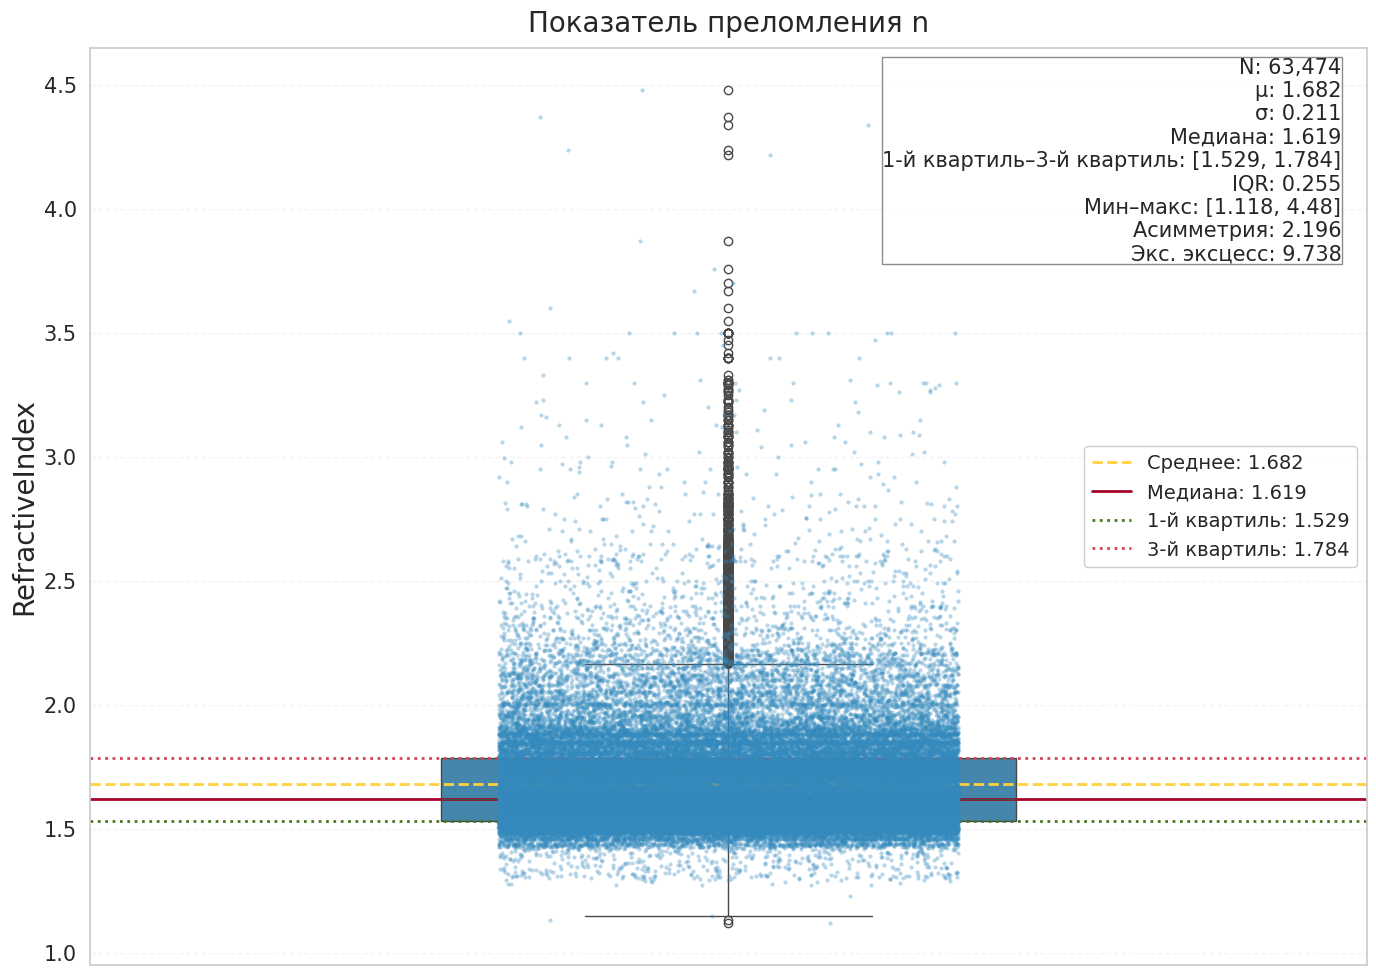

Значения 'RefractiveIndex' больше среднего + 3 квартиль:


In [112]:
plot_boxplot(
    merged_data,
    'RefractiveIndex',
    title='Показатель преломления n',
    bins=60,
)

# Найти выбросы: значения, больше чем среднее + 3-й квартиль
refr_index = merged_data['RefractiveIndex'].dropna()
mean_val = refr_index.mean()
q3 = refr_index.quantile(0.75)
threshold = mean_val + q3

outliers = merged_data[merged_data['RefractiveIndex'] > threshold]

print("Значения 'RefractiveIndex' больше среднего + 3 квартиль:")
if outliers.shape[0] == 0:
    print("Не найдено выбросов.")
else:
    outliners = (pd.DataFrame(outliers))

In [114]:
outliners.describe()

,Kod,GLASNO,H,Li,Be,B,C,N,O,F,Na,Mg,Al,Si,P,S,Cl,K,Ca,Sc,Ti,V,Cr,Mn,Fe,Co,Ni,Cu,Zn,Ga,Ge,As,Se,Br,Rb,Sr,Y,Zr,Nb,Mo,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,Th,U,KOD,A_WT,M_WT,SIO2,AL2O3,B2O3,CAO,K2O,NA2O,PBO,Li2O,MgO,SRO,BAO,ZNO,P2O5,GEO2,ZRO2,TIO2,TEO2,RO,FemOn,WSIO2,WAL2O3,WB2O3,WCAO,WK2O,WNA2O,WPBO,WLi2O,WMgO,WSRO,WBAO,WZNO,WGEO2,WZRO2,WTIO2,WTEO2,WRO,WFemOn,WP2O5,T0,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,Viscosity773K,Viscosity873K,Viscosity973K,Viscosity1073K,Viscosity1173K,Viscosity1273K,Viscosity1373K,Viscosity1473K,Viscosity1573K,Viscosity1673K,Viscosity1773K,Viscosity1873K,Viscosity2073K,Viscosity2273K,Viscosity2473K,Tg,TLittletons,TAnnealing,Tstrain,Tsoft,Resistivity423K,Resistivity573K,Resistivity293K,Resistivity373K,TresistivityIs1MOhm.m,CTE328K,CTE373K,CTE433K,CTE483K,CTE623K,CTEbelowTg,Density293K,spvm,RefractiveIndex,RefractiveIndexLow,RefractiveIndexHigh,MeanDispersion,AbbeNum,ThermalShockRes,YoungModulus,ShearModulus,Microhardness,Permittivity,TangentOfLossAngle,Resistivity1073K,Resistivity1273K,Resistivity1473K,Resistivity1673K,Tmelt,Tliquidus,SurfaceTension1173K,SurfaceTension1473K,SurfaceTension1573K,SurfaceTension1673K,SurfaceTensionAboveTg,QComp,QComp2,ThermalConductivity,PoissonRatio,TdilatometricSoftening,Flag,Cp293K,Cp473K,Cp673K,Cp1073K,Cp1273K,Cp1473K,Cp1673K,Density1073K,Density1273K,Density1473K,Density1673K,AsmOn,Bi2O3,R2O,R2O3,RF,RF2,RF3,RF4,RF5,RHal,RHal2,RHal3,RHal4,RHal5,RHaln,RmOn,RmNn,SbmOn,VmOn,WO3,wBi2O3,wR2O,wR2O3,wRF,wRF2,wRF3,wRF4,wRF5,wRHal,wRHal2,wRHal3,wRHal4,wRHal5,wRHaln,wRmNn,wWO3,wRmOn,Year,RO2,R2O5,RO3,RO4,WRO2,WR2O5,WRO3,WRO4,GForm,any_n,TMaxGrowthVelocity,MaxGrowthVelocity,NucleationTemperature,NucleationRate,CrystallizationPeak,CrystallizationOnset
count,23.000000,23.000000,23.0,23.0,23.0,23.0,23.0,23.0,23.000000,23.0,23.000000,23.0,23.000000,23.000000,23.000000,23.000000,23.0,23.000000,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.000000,23.000000,23.000000,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.000000,23.00000,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.000000,23.0,23.000000,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.000000,23.0,23.0,23.0,23.0,23.000000,23.000000,23.000000,23.0,23.000000,23.0,23.0,23.000000,23.000000,23.000000,23.0,23.0,23.0,23.0,23.0,23.00000,23.0,23.0,23.0,23.0,23.000000,23.0,23.0,23.000000,23.0,23.0,23.000000,23.000000,23.000000,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.000000,23.0,23.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.00000,5.000000,0.0,6.000000,5.000000,3.000000,0.0,0.0,1.000000,0.0,0.0,2.000000,9.000000,9.000000,23.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.000000,23.000000,0.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,23.0,23.000000,23.000000,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.000000,23.0,23.0,23.0,23.0,23.0,23.000000,23.000000,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.000000,23.000000,23.0,23.00000,23.0,0.0,23.0,23.000000,23.0,0.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,30827.391304,390280.000000,0.0,0.0,0.0,0.0,0.0,0.0,8.168621,0.0,0.327123,0.0,0.490684,0.709565,4.138031,3.777467,0.0,0.926848,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.662098,21.992174,10.987739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.173913,40.04487,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054520,0.0,0.099593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.446754,0.0,0.0,0.0,0.0,30827.391304,89.219841,200.949372,0.0,1.173913,0.0,0.0,2.217391,0.782609,2.760870,0.0,0.0,0.0,0.0,0.0,5.73913,0.0,0.0,0.0,0.0,2.760870,0.0,0.0,0.799892,0.0,0.0,1.395838,0.324152,4.120472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.120472,0.0,5.444083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

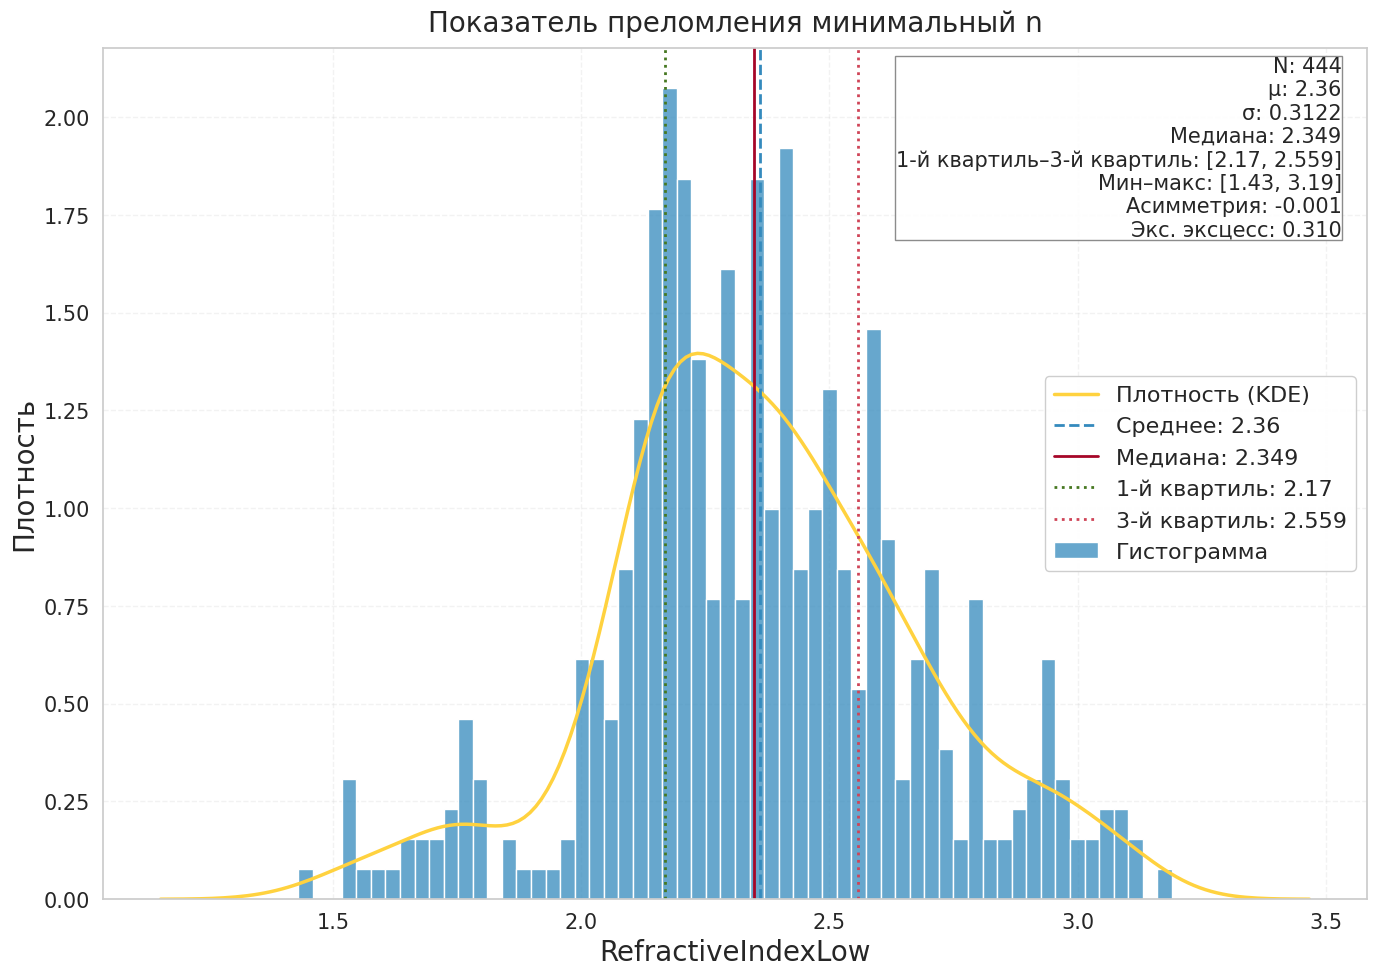

In [102]:
plot_distribution(
    merged_data,
    'RefractiveIndexLow',
    title='Показатель преломления минимальный n',
    bins=60,
)

In [ ]:
#here

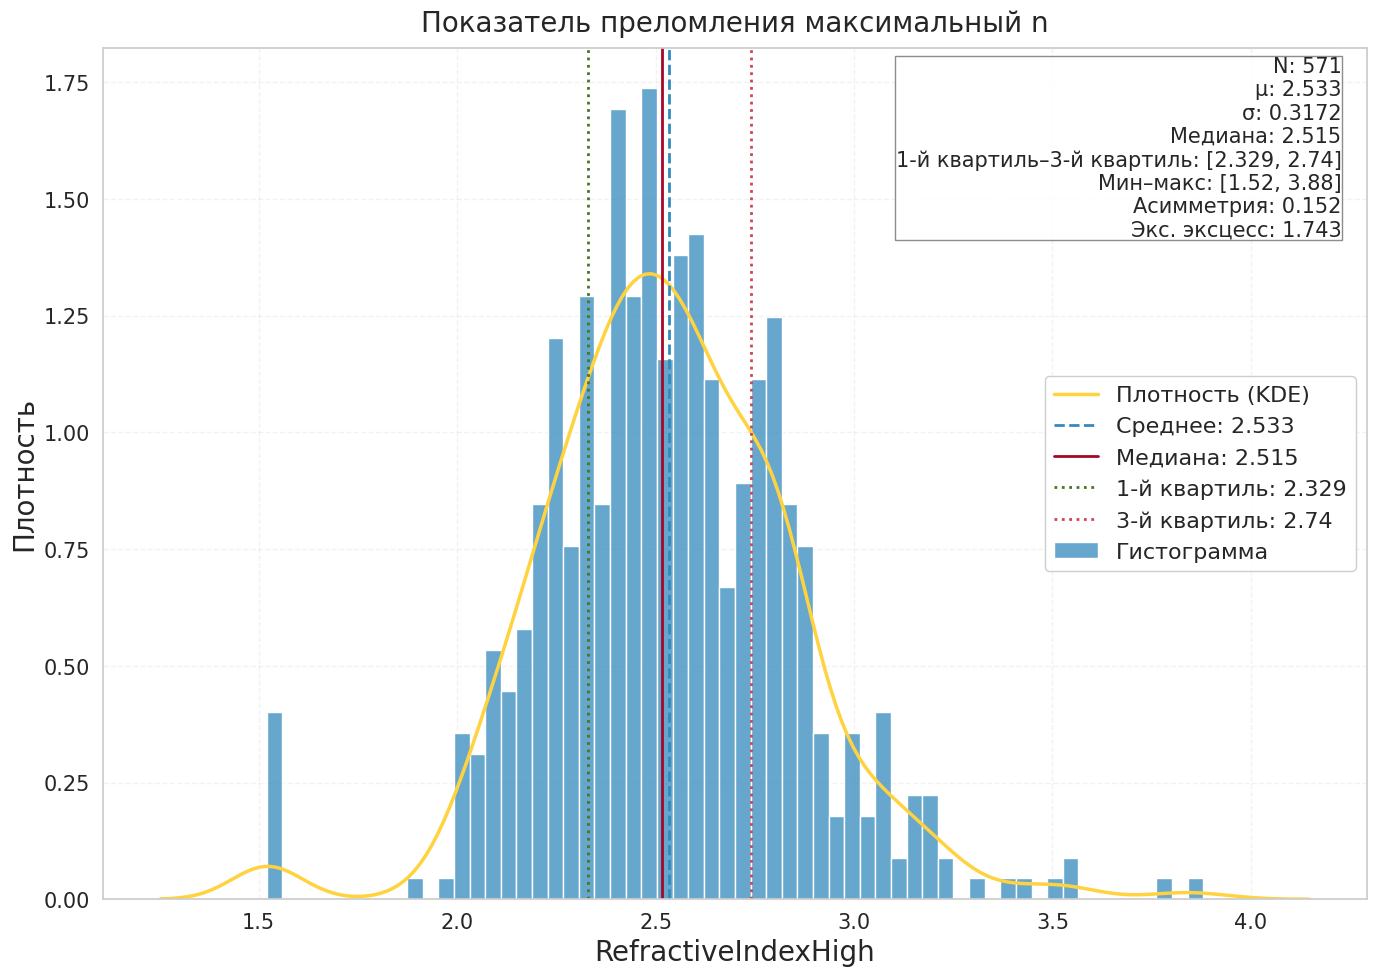

In [104]:
plot_distribution(
    merged_data,
    'RefractiveIndexHigh',
    title='Показатель преломления максимальный n',
    bins=60,
)

C:\Temp\ipykernel_3068\3801576694.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_data['RefractiveIndexLow'].dropna())


<Axes: xlabel='RefractiveIndexLow', ylabel='Density'>

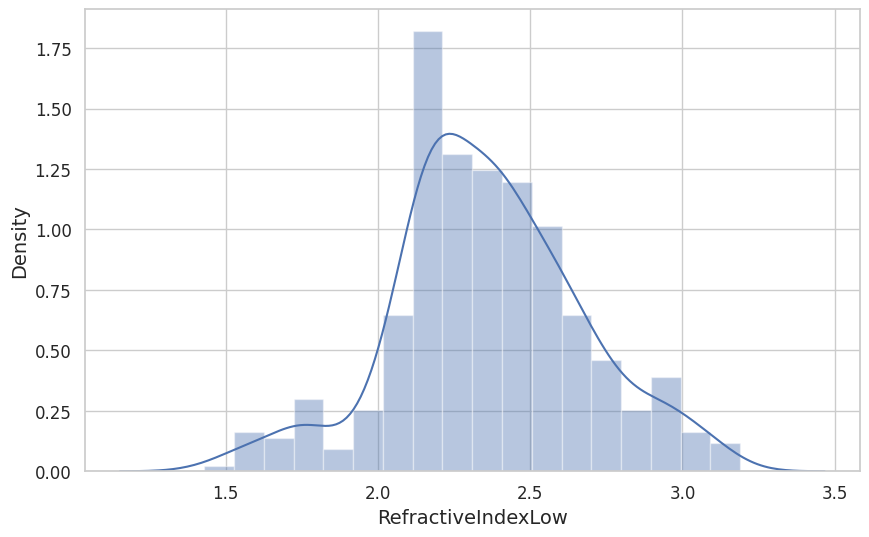

In [67]:
sns.distplot(merged_data['RefractiveIndexLow'].dropna())

C:\Temp\ipykernel_3068\2004853027.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_data['RefractiveIndexHigh'].dropna())


<Axes: xlabel='RefractiveIndexHigh', ylabel='Density'>

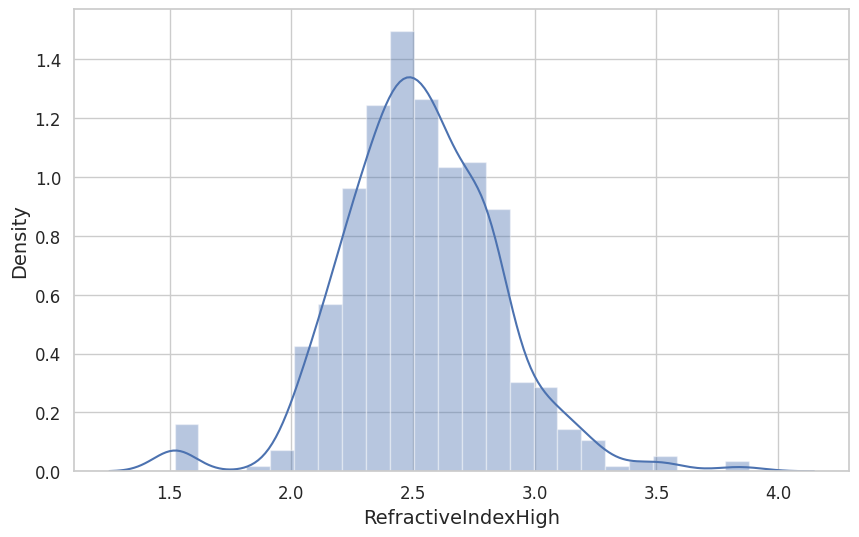

In [68]:
sns.distplot(merged_data['RefractiveIndexHigh'].dropna())

In [ ]:
# Сначала отбираем ID стёкол с n + v
has_n = df_props['RefractiveIndex'].replace(0, np.nan).notna()
# has_v = df_props['AbbeNumber'].replace(0, np.nan).notna()
# opt_ids = set(df_props[has_n & has_v].index)
# print(f'Стёкол с n и v: {len(opt_ids):,}')

NameError: name 'has_v' is not defined

In [ ]:
# Парсим состав только для нужных ID
records = []
with zipfile.ZipFile(DATA_DIR / 'select_Gcomp.csv.zip') as z:
    with z.open(z.namelist()[0]) as f:
        raw = pd.read_csv(f, sep='\t', low_memory=False)

raw['ID'] = raw['Kod'] * 100_000_000 + raw['GlasNo']
raw = raw[raw['ID'].isin(opt_ids)].drop_duplicates('ID').set_index('ID')

# Парсим строку состава вида |SiO2|mol|61.5|wt|...
def parse_comp(s):
    if not isinstance(s, str): return {}
    parts = s.strip('|').split('\x7f')
    return {parts[n*4]: float(parts[n*4+3]) for n in range(len(parts)//4)
            if len(parts) > n*4+3 and parts[n*4+3].replace('.','').lstrip('-').isdigit()}

comp_list = [parse_comp(row) for row in raw['Composition'].values]
df_comp = pd.DataFrame(comp_list, index=raw.index).fillna(0)
print(f'Состав (оксиды): {df_comp.shape[0]:,} стёкол x {df_comp.shape[1]} компонентов')

## 4. Объединённый датасет SciGlass

In [ ]:
df_sciglass = df_props.join(df_elem, how='left', rsuffix='_at').join(df_comp, how='left')
df_sciglass = df_sciglass[
    df_sciglass['RefractiveIndex'].replace(0,np.nan).notna() &
    df_sciglass['AbbeNumber'].replace(0,np.nan).notna()
]
print(f'SciGlass итог: {df_sciglass.shape[0]:,} записей x {df_sciglass.shape[1]} колонок')
df_sciglass[['RefractiveIndex','AbbeNumber','Density','TransitionTemperature']].describe().round(3)

In [ ]:
df_sciglass.to_parquet('sciglass_optical.parquet')
print('Сохранено: sciglass_optical.parquet')

## 5. SCHOTT каталог (PDF)
nd, vd, плотность, Tg коммерческих марок. Состав не публикуется.

In [ ]:
from pypdf import PdfReader
import re

reader = PdfReader('schott_catalog.pdf')
text = ''.join(p.extract_text() or '' for p in reader.pages)
print(f'Страниц: {len(reader.pages)}, символов: {len(text):,}')
print(text[:1000])

In [ ]:
# Ищем строки вида: N-BK7  1.5168  64.17  2.51  557
# Паттерн: марка  nd   vd   density  Tg
pattern = r'([A-Z][A-Z0-9\-]+)\s+(1\.\d{3,4})\s+(\d{2,3}\.\d{1,2})\s+(\d\.\d{2})\s+(\d{3,4})'
rows = []
for m in re.finditer(pattern, text):
    rows.append({
        'glass': m.group(1),
        'nd': float(m.group(2)),
        'vd': float(m.group(3)),
        'density': float(m.group(4)),
        'Tg': float(m.group(5)),
    })

df_schott = pd.DataFrame(rows).drop_duplicates('glass')
print(f'SCHOTT: {len(df_schott)} марок извлечено')
df_schott.head(10)

In [ ]:
df_schott.to_csv('schott_glasses.csv', index=False)
print('Сохранено: schott_glasses.csv')

## Итог

In [ ]:
print('=== Загруженные данные ===')
print(f'SciGlass (sciglass_optical.parquet): {len(df_sciglass):,} стёкол')
print(f'SCHOTT   (schott_glasses.csv)       : {len(df_schott)} марок')
print()
print('Ключевые свойства в SciGlass:')
for p in ['RefractiveIndex','AbbeNumber','Density','TransitionTemperature','CTE']:
    if p in df_sciglass.columns:
        nn = df_sciglass[p].replace(0,np.nan).dropna()
        print(f'  {p:30s}: {len(nn):,}')